In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.DataFrame(pd.read_csv("Fish.csv"))
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [3]:
x = df[["Weight"]]
y = df["Length3"]
X_train, X_test, Y_Train, Y_test = train_test_split(x,y, test_size=0.3, random_state=42)
model = LinearRegression()
z = model.fit(X_train, Y_Train)
pre = model.predict(X_test)
print(r2_score(Y_test,pre))
print(pre)

0.8297892484883528
[21.88846553 19.97544223 25.50129589 27.57423135 24.02062771 49.19198683
 19.78591671 24.90902862 25.14593553 56.59532775 38.82730954 49.19198683
 37.34664136 24.02062771 40.30797773 46.82291773 49.19198683 26.03433644
 26.24162999 40.30797773 19.8747568  37.642775   34.38530499 34.38530499
 47.85938546 52.1533232  24.61289498 27.57423135 19.7770327  19.87179546
 34.68143863 21.65155862 21.10371139 36.36940036 29.64716681 23.1322268
 24.31676135 23.1322268  23.87256089 43.86158137 40.900245   34.38530499
 19.80072339 22.83609316 23.72449407 21.62194525 22.83609316 37.93890863]


{1: 0.9096349552643738, 2: 0.9190213040666667, 3: 0.8816867161493223, 4: 0.9318041328255938, 42: 0.937992131779537}


<Axes: >

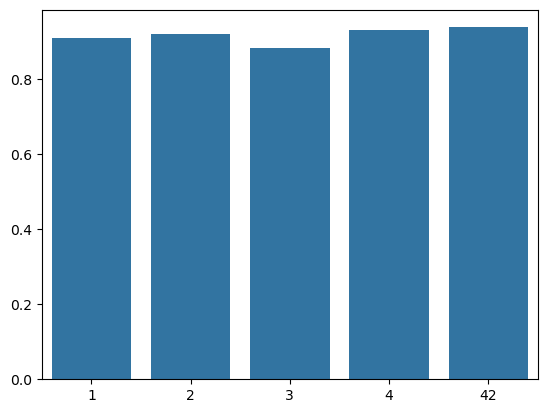

In [4]:
x = df[["Length1","Length2","Length3","Height","Width","Species"]]
y = df["Weight"]
x = pd.get_dummies(x)
dic = {}
for i in [1,2,3,4,42]:
    X_train, X_test, Y_Train, Y_test = train_test_split(x,y, test_size=0.3, random_state=i)
    model = LinearRegression()
    z = model.fit(X_train, Y_Train)
    pre = model.predict(X_test)
    r2 = r2_score(Y_test,pre)
    dic[i] = r2
print(dic)    
sns.barplot(x=list(dic.keys()), y=list(dic.values()))

In [12]:
x = df[["Length1","Length2","Length3","Height","Width","Species"]]
y = df["Weight"]
x = pd.get_dummies(x)

X_train, X_test, Y_Train, Y_test = train_test_split(x,y, test_size=0.3, random_state=42)
lis = []
poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(X_train)
x_test_poly = poly.transform(X_test)

model = LinearRegression()
z = model.fit(x_train_poly, Y_Train)
pre = model.predict(x_test_poly)
r2 = r2_score(Y_test,pre)
print(r2)
pre = model.predict(poly.transform([[23.6,26,28.7,8.3804,4.2476,0,0,0,0,0,0,1]])) 
print(pre)

0.973811120841621
[214.28838917]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
